# 03. Carga politécnica disponible

**Fuente:** `data/raw/cargapolitecnicadisponible.csv`  
**Salida:** `data/processed/carga_politecnica_disponible.csv`

Registra las responsabilidades de gestión institucional, cargos administrativos, comisiones y actividades no docentes asignadas al personal en cada período académico (horas dedicadas, tipo de función, unidad académica u operativa). Aporta variables clave sobre liderazgo, gestión y servicio politécnico.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

In [2]:
df = pc.leer_csv('cargapolitecnicadisponible.csv', low_memory=False)
df.head()

Leido cargapolitecnicadisponible.csv con encoding=utf-8-sig -> 48709 filas, 33 columnas


,IDPERSONA,NUMEROIDENTIFICACION,NOMDOCENTE,EMAIL,EMAILALTERNO,ANIO,TERMINO1,TERMINO2,TERMINO3,IDUNIDAD,IDUNIDADCARGA,NUMHORASCP,OBSERVACIONCP,NOMFUNCION,DESCFUNCION,IDPERIODO,VALOR,CODACADCARGA,NOMBREUNIDADCARGA,CODACAD,NOMBREUNIDAD,PERIODICIDAD,NUMHORAS,NIVELESTUDIO,NIVELGRADO,TERMINON1,TERMINON2,TERMINON3,APROBADO,IDTIPOACTIVIDAD,ACTIVIDAD,IDCENTRO,IDACTIVIDAD
0,37954,0920713526,ALMEIDA PAZMIÑO GONZALO ALFONSO,galmeida@espol.edu.ec,g_almeida_81@hotmail.com,2014,1.0,2.0,NaN,15007,15007,160,CARRERA IM,CONSEJERO ACADÉMICO,CARRERA IM,2014,Docencia,FIMP,Facultad de Ingeniería en Mecánica y Ciencias ...,FIMP,Facultad de Ingeniería en Mecánica y Ciencias ...,SEMANAL,4,R,PREGRADO,PRIMER TÉRMINO,SEGUNDO TÉRMINO,CURSO VACACIONAL,N,5,D,NaN,97
1,54259,0926470279,VILLACÍS TAGLE JACQUELINE ALEXANDRA,jaalvill@espol.edu.ec,jaktagle23@hotmail.com,2015,1.0,2.0,NaN,15249,15249,200,IINFORME SEMESTRAL A TRAVES DEL COORDINADOR DE...,PARTICIPACIÓN EN PROYECTO DE VÍNCULOS CON LA S...,IINFORME SEMESTRAL A TRAVES DEL COORDINADOR DE...,2015,Vínculos con la Colectividad,EDCOM,Escuela de Diseño y Comunicación Visual,EDCOM,Escuela de Diseño y Comunicación Visual,SEMANAL,5,R,PREGRADO,PRIMER TÉRMINO,SEGUNDO TÉRMINO,CURSO VACACIONAL,S,266,V,NaN,8573
2,53697,0925477457,JIMENEZ MIRANDA JOSÉ DAVID,jodajime@espol.edu.ec,zedavid88@hotmail.com,2016,1.0,2.0,NaN,15009,15287,200,COORDINADOR LAB. FISICA A,JEFE DE LABORATORIO DE DOCENCIA,COORDINADOR LAB. FISICA A,2016,Gestión Administrativa,FCNM,Facultad de Ciencias Naturales y Matemáticas,ICF,Instituto de Ciencias Físicas,SEMANAL,5,R,PREGRADO,PRIMER TÉRMINO,SEGUNDO TÉRMINO,CURSO VACACIONAL,S,582,A,NaN,13923
3,4860,0925018632,LOPEZ AGUIRRE MARIUXI ARACELY,marlopez@espol.edu.ec,lopmariuxi@gmail.com,2015,NaN,2.0,3.0,15008,15008,27,ARTÍCULO FEN OPINA.,ARTICULO ACADEMICO,ARTÍCULO FEN OPINA.,2015,Docencia,ICHE,Facultad de Ciencias Sociales y Humanísticas,ICHE,Facultad de Ciencias Sociales y Humanísticas,SEMANAL,1,R,PREGRADO,PRIMER TÉRMINO,SEGUNDO TÉRMINO,CURSO VACACIONAL,S,318,D,NaN,8575
4,76214,0910561372,ZURITA HURTADO HARRY ALFREDO,hazurita@espol.edu.ec,harry.zurita@gmail.com,2015,1.0,2.0,3.0,15287,15287,141,REUNIONES CONVOCADAS POR FCNM,ASISTENCIA Y PARTICIPACIÓN EN REUNIONES Y/O AC...,REUNIONES CONVOCADAS POR FCNM,2015,Docencia,FCNM,Facultad de Ciencias Naturales y Matemáticas,FCNM,Facultad de Ciencias Naturales y Matemáticas,SEMANAL,3,R,PREGRADO,PRIMER TÉRMINO,SEGUNDO TÉRMINO,CURSO VACACIONAL,S,259,D,NaN,8576


## 2. Exploración inicial

In [3]:
pc.resumen(df, 'carga_politecnica_disponible')

--- Resumen carga_politecnica_disponible ---
Dimensiones: 48709 filas x 33 columnas
Filas duplicadas: 0
Columnas con nulos (%):
IDCENTRO         99.3
TERMINO3         54.6
TERMINO1         19.9
TERMINO2         15.3
PERIODICIDAD      3.1
EMAILALTERNO      1.4
EMAIL             0.8
APROBADO          0.6
CODACADCARGA      0.1
CODACAD           0.1
DESCFUNCION       0.0
OBSERVACIONCP     0.0
dtype: float64


In [4]:
# 1. Normalizar las columnas de términos

columnas_terminos = ['TERMINO1', 'TERMINO2', 'TERMINO3']

for col in columnas_terminos:
    df[col] = ( df[col].fillna('').astype(str).str.strip())

In [5]:
# 2. Crear indicadores de aplicación por término

df['APLICA_T1'] = (df['TERMINO1'] != '').astype(int)
df['APLICA_T2'] = (df['TERMINO2'] != '').astype(int)
df['APLICA_T3'] = (df['TERMINO3'] != '').astype(int)

In [6]:
# 3. Número de términos en los que aplica la actividad

df['NUM_TERMINOS'] = ( df['APLICA_T1'] + df['APLICA_T2'] + df['APLICA_T3'])

In [7]:
# 4. Crear una representación legible de los términos

def consolidar_terminos(row):
    activos = []
    if row['APLICA_T1'] == 1:
        activos.append('1')
    if row['APLICA_T2'] == 1:
        activos.append('2')
    if row['APLICA_T3'] == 1:
        activos.append('3')
    return '-'.join(activos) if activos else 'SIN_TERMINO'


df['TERMINOS_ACTIVOS'] = df.apply( consolidar_terminos, axis=1)


In [8]:
df = df.drop( columns=['TERMINO1', 'TERMINO2', 'TERMINO3'], errors='ignore'
)

In [9]:
pc.resumen(df, 'carga_politecnica_disponible')

--- Resumen carga_politecnica_disponible ---
Dimensiones: 48709 filas x 35 columnas
Filas duplicadas: 0
Columnas con nulos (%):
IDCENTRO         99.3
PERIODICIDAD      3.1
EMAILALTERNO      1.4
EMAIL             0.8
APROBADO          0.6
CODACAD           0.1
CODACADCARGA      0.1
OBSERVACIONCP     0.0
DESCFUNCION       0.0
dtype: float64


In [10]:
df.dtypes

IDPERSONA                 int64
NUMEROIDENTIFICACION        str
NOMDOCENTE                  str
EMAIL                       str
EMAILALTERNO                str
ANIO                      int64
IDUNIDAD                  int64
IDUNIDADCARGA             int64
NUMHORASCP                int64
OBSERVACIONCP               str
NOMFUNCION                  str
DESCFUNCION                 str
IDPERIODO                 int64
VALOR                       str
CODACADCARGA                str
NOMBREUNIDADCARGA           str
CODACAD                     str
NOMBREUNIDAD                str
PERIODICIDAD                str
NUMHORAS                  int64
NIVELESTUDIO                str
NIVELGRADO                  str
TERMINON1                   str
TERMINON2                   str
TERMINON3                   str
APROBADO                    str
IDTIPOACTIVIDAD           int64
ACTIVIDAD                   str
IDCENTRO                float64
IDACTIVIDAD               int64
APLICA_T1                 int64
APLICA_T

## 3. Limpieza

In [11]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_vacias(df, umbral=0.99)
df = pc.quitar_columnas_constantes(df, excluir=["TERMINON1", "TERMINON2", "TERMINON3"])

Columnas eliminadas por tener >= 99% de nulos: ['IDCENTRO']


In [12]:
df = df.drop(columns=['EMAILALTERNO'], errors='ignore')
df = df.drop(columns=['EMAIL'], errors='ignore')

## 5. Tipado de fechas e identificadores

In [13]:
df = pc.castear_fechas(df, ['FECHAAPROBPLANIF', 'FECHAINICIOREGIST', 'FECHA_INICIO', 'FECHA_FIN'])
df = pc.castear_enteros(df, ['IDPERSONA', 'IDCURSO', 'IDUNIDAD', 'IDUNIDADCARGA', 'IDMATERIA', 'IDTIPOACTIVIDAD', 'IDPERIODO', 'IDCPLCAMBIOSCURSO'])
df = pc.convertir_sn_a_binario(df, ['APROBADO'])

Columnas S/N convertidas a binario (1/0): ['APROBADO']


## Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Actividades de carga politécnica por año**.

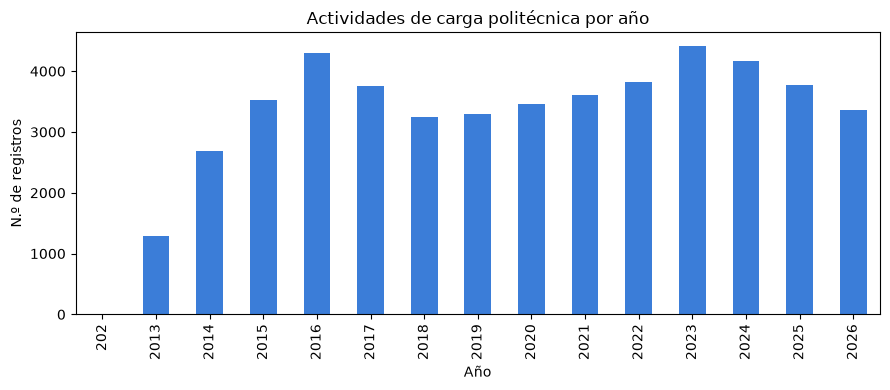

In [15]:
conteo_anio = df['ANIO'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
conteo_anio.plot(kind='bar', ax=ax, color=pc.COLOR_PRINCIPAL)
ax.set_title('Actividades de carga politécnica por año')
ax.set_xlabel('Año'); ax.set_ylabel('N.º de registros')
plt.tight_layout()

**Unidades con más actividades de carga politécnica** (gestión, comisiones, direcciones).

<Axes: title={'center': 'Top 10 unidades por actividades de carga politécnica'}, ylabel='NOMBREUNIDAD'>

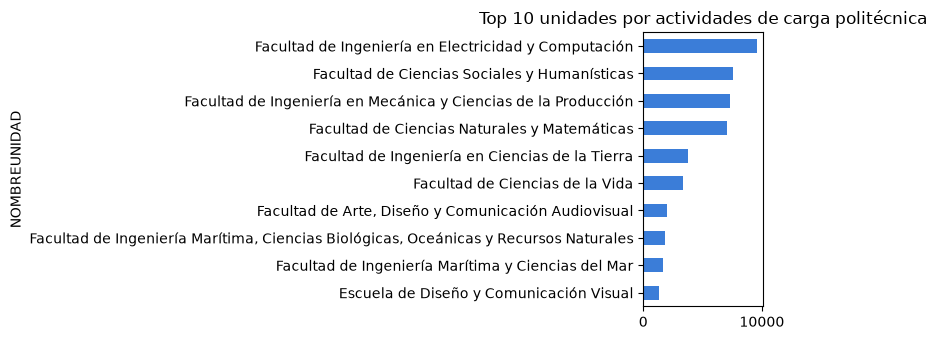

In [16]:
pc.grafico_barras(df['NOMBREUNIDAD'], 'Top 10 unidades por actividades de carga politécnica', top=10)

**Número de términos en los que aplica cada actividad** (variable derivada NUM_TERMINOS).

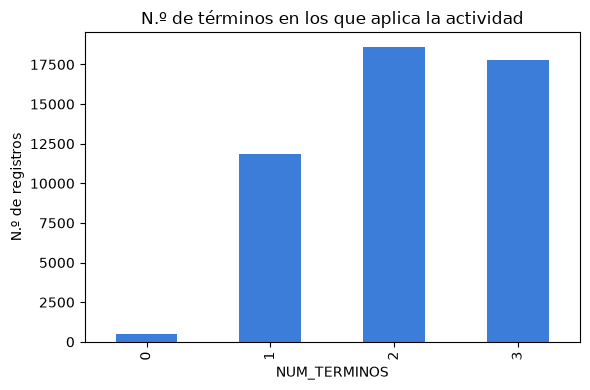

In [17]:
conteo_terminos = df['NUM_TERMINOS'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
conteo_terminos.plot(kind='bar', ax=ax, color=pc.COLOR_PRINCIPAL)
ax.set_title('N.º de términos en los que aplica la actividad')
ax.set_xlabel('NUM_TERMINOS'); ax.set_ylabel('N.º de registros')
plt.tight_layout()

## 7. Verificación final

In [19]:
pc.resumen(df, 'carga_politecnica_disponible (procesado)')
df.head()

--- Resumen carga_politecnica_disponible (procesado) ---
Dimensiones: 48709 filas x 32 columnas
Filas duplicadas: 0
Columnas con nulos (%):
PERIODICIDAD     3.1
CODACADCARGA     0.1
CODACAD          0.1
OBSERVACIONCP    0.0
DESCFUNCION      0.0
dtype: float64


,IDPERSONA,NUMEROIDENTIFICACION,NOMDOCENTE,ANIO,IDUNIDAD,IDUNIDADCARGA,NUMHORASCP,OBSERVACIONCP,NOMFUNCION,DESCFUNCION,IDPERIODO,VALOR,CODACADCARGA,NOMBREUNIDADCARGA,CODACAD,NOMBREUNIDAD,PERIODICIDAD,NUMHORAS,NIVELESTUDIO,NIVELGRADO,TERMINON1,TERMINON2,TERMINON3,APROBADO,IDTIPOACTIVIDAD,ACTIVIDAD,IDACTIVIDAD,APLICA_T1,APLICA_T2,APLICA_T3,NUM_TERMINOS,TERMINOS_ACTIVOS
0,37954,0920713526,ALMEIDA PAZMIÑO GONZALO ALFONSO,2014,15007,15007,160,CARRERA IM,CONSEJERO ACADÉMICO,CARRERA IM,2014,Docencia,FIMP,Facultad de Ingeniería en Mecánica y Ciencias ...,FIMP,Facultad de Ingeniería en Mecánica y Ciencias ...,SEMANAL,4,R,PREGRADO,PRIMER TÉRMINO,SEGUNDO TÉRMINO,CURSO VACACIONAL,0,5,D,97,1,1,0,2,1-2
1,54259,0926470279,VILLACÍS TAGLE JACQUELINE ALEXANDRA,2015,15249,15249,200,IINFORME SEMESTRAL A TRAVES DEL COORDINADOR DE...,PARTICIPACIÓN EN PROYECTO DE VÍNCULOS CON LA S...,IINFORME SEMESTRAL A TRAVES DEL COORDINADOR DE...,2015,Vínculos con la Colectividad,EDCOM,Escuela de Diseño y Comunicación Visual,EDCOM,Escuela de Diseño y Comunicación Visual,SEMANAL,5,R,PREGRADO,PRIMER TÉRMINO,SEGUNDO TÉRMINO,CURSO VACACIONAL,1,266,V,8573,1,1,0,2,1-2
2,53697,0925477457,JIMENEZ MIRANDA JOSÉ DAVID,2016,15009,15287,200,COORDINADOR LAB. FISICA A,JEFE DE LABORATORIO DE DOCENCIA,COORDINADOR LAB. FISICA A,2016,Gestión Administrativa,FCNM,Facultad de Ciencias Naturales y Matemáticas,ICF,Instituto de Ciencias Físicas,SEMANAL,5,R,PREGRADO,PRIMER TÉRMINO,SEGUNDO TÉRMINO,CURSO VACACIONAL,1,582,A,13923,1,1,0,2,1-2
3,4860,0925018632,LOPEZ AGUIRRE MARIUXI ARACELY,2015,15008,15008,27,ARTÍCULO FEN OPINA.,ARTICULO ACADEMICO,ARTÍCULO FEN OPINA.,2015,Docencia,ICHE,Facultad de Ciencias Sociales y Humanísticas,ICHE,Facultad de Ciencias Sociales y Humanísticas,SEMANAL,1,R,PREGRADO,PRIMER TÉRMINO,SEGUNDO TÉRMINO,CURSO VACACIONAL,1,318,D,8575,0,1,1,2,2-3
4,76214,0910561372,ZURITA HURTADO HARRY ALFREDO,2015,15287,15287,141,REUNIONES CONVOCADAS POR FCNM,ASISTENCIA Y PARTICIPACIÓN EN REUNIONES Y/O AC...,REUNIONES CONVOCADAS POR FCNM,2015,Docencia,FCNM,Facultad de Ciencias Naturales y Matemáticas,FCNM,Facultad de Ciencias Naturales y Matemáticas,SEMANAL,3,R,PREGRADO,PRIMER TÉRMINO,SEGUNDO TÉRMINO,CURSO VACACIONAL,1,259,D,8576,1,1,1,3,1-2-3


## 8. Guardado en data/processed

In [20]:
pc.guardar_procesado(df, 'carga_politecnica_disponible.csv')

Guardado: D:\Proyecto_Tesis\data\processed\carga_politecnica_disponible.csv (48709 filas x 32 columnas)


WindowsPath('D:/Proyecto_Tesis/data/processed/carga_politecnica_disponible.csv')